# 1. Quickstart — your first tracker

This is a 10-minute introduction to **unitrack**, the PyTorch-native
multi-object tracking library. By the end of this notebook you will:

- understand what a unitrack `Tracker` *is* (a pure step function),
- build a minimal tracker that matches detections by appearance,
- run it on a synthetic clip and visualize the resulting tracks.

Subsequent tutorials drill down into each part of the library:
the data model (notebook 2), the cost & gate zoos (3), the
composable pipeline tree (4), state evolution and lifecycle (5),
and a paper-style end-to-end reproduction (6).


## What is a tracker?

A tracker associates **detections** (per-frame outputs of an object
detector) into **tracklets** (per-identity sequences over time).
unitrack's central abstraction is:

```
Tracker.step(snapshot, detections, ctx, next_id) → (snapshot', match, ids, next_id')
```

- `snapshot` is the **current state** of the tracker — a typed,
  immutable record of every live tracklet's fields (id, status,
  age, kernel embedding, position, mask, …).
- `detections` is one frame's worth of new observations.
- `ctx` carries timing and stream-identity metadata.
- `next_id` is a counter passed in by the caller for assigning new
  tracklet IDs.

The tracker is a **pure function**. It doesn't mutate its inputs;
it returns a fresh snapshot. The convenience wrapper
`MultiStream` holds the snapshot for you, so you don't have to
thread `next_id` and the snapshot through every call.


In [7]:
# The full set of imports we'll use across this notebook.
import torch
import matplotlib.pyplot as plt

import unitrack
from unitrack.assignment import Associate, Jonker
from unitrack.costs import Cosine
from unitrack.data import Detections, FrameContext, TensorSpec
from unitrack.lifecycle import IncludeAll, NoLifecycle
from unitrack.pipeline import Pipe
from unitrack.states import FromDetectionField, Identity, Replace, State

torch.manual_seed(0)
plt.rcParams["figure.figsize"] = (6, 4)


## A minimal tracker

We'll build the simplest meaningful tracker: it matches detections
across frames by **cosine similarity over a learned kernel embedding**.

The construction reads top-down like a recipe:

- **State**: each tracklet carries a `kernel` field (a 4-dim float
  vector). `Identity` means the predict step is a no-op (the
  embedding doesn't drift between frames). `Replace` means matched
  tracklets adopt the new detection's embedding. `FromDetectionField`
  says "when a new tracklet is created, copy this field from the
  detection that spawned it."
- **Stage tree**: a single `Pipe` that computes a cosine-distance
  cost matrix and hands it to `Associate`, which runs Jonker–Volgenant
  assignment with a 0.5 threshold.
- **Lifecycle / Visibility**: `NoLifecycle` (no Tentative→Active
  transitions) and `IncludeAll` (every tracklet is visible to the
  caller). The next tutorial introduces the proper lifecycle policy.


In [8]:
tracker = unitrack.Tracker(
    root=Pipe(cost=Cosine("kernel"), assoc=Associate(Jonker(threshold=0.5))),
    states={
        "kernel": State(
            schema=TensorSpec(shape=(4,), dtype=torch.float32),
            process=Identity("kernel"),
            observation=Replace("kernel"),
            init=FromDetectionField("kernel"),
        ),
        # `position` isn't used for matching here; we carry it on
        # the snapshot so the visualization below has a 2D point
        # to draw per tracklet.
        "position": State(
            schema=TensorSpec(shape=(2,), dtype=torch.float32),
            process=Identity("position"),
            observation=Replace("position"),
            init=FromDetectionField("position"),
        ),
    },
    lifecycle=NoLifecycle(),
    visibility=IncludeAll(),
)

ms = unitrack.MultiStream(tracker)
print(tracker)


## A tiny synthetic clip

We'll generate three "ground-truth" objects, each with a unique
kernel embedding plus a 2D position that drifts at constant velocity.
Across frames the detection order is **shuffled** so the tracker
can't trivially exploit row alignment — it has to use the kernel
embedding to reassociate.


In [9]:
N_FRAMES, N_OBJS, K_DIM = 8, 3, 4

# Per-identity ground truth.
kernels = torch.randn(N_OBJS, K_DIM)
kernels = kernels / kernels.norm(dim=-1, keepdim=True)
positions = torch.tensor([[20.0, 50.0], [100.0, 30.0], [180.0, 80.0]])
velocities = torch.tensor([[3.0, 1.0], [-1.0, 2.0], [-2.0, -1.0]])

clip = []
gt_per_frame = []
for k in range(N_FRAMES):
    order = torch.randperm(N_OBJS)
    gt_per_frame.append(order)

    kernel_obs = kernels[order] + 0.02 * torch.randn(N_OBJS, K_DIM)
    kernel_obs = kernel_obs / kernel_obs.norm(dim=-1, keepdim=True)
    pos_obs = positions[order] + k * velocities[order]

    clip.append(
        Detections(
            index=torch.arange(N_OBJS, dtype=torch.int64),
            kernel=kernel_obs.float(),
            position=pos_obs.float(),
            batch_size=[N_OBJS],
        )
    )
gt_per_frame = torch.stack(gt_per_frame)
print(f"Generated {N_FRAMES} frames of {N_OBJS} detections each.")


Generated 8 frames of 3 detections each.


Note `Detections` accepts arbitrary user fields (`kernel`, `position`)
beyond its single reserved field `index`. The same is true of
`Tracklets`. unitrack's typed-record story is intentionally
permissive about user fields so you can plug in whatever your
detector emits — kernels, masks, depth, classes, scores, …


## What does the clip look like?

Before we track anything, let's *see* what we just generated —
the two cues the tracker will rely on:

- **Left (2D motion)**: each object's ground-truth position over
  the eight frames. This is the world the tracker observes,
  modulo per-frame shuffling.
- **Right (appearance space)**: the cosine similarity between the
  three identities' kernel embeddings. The near-identity matrix
  (1 on the diagonal, ≈0 off it) is exactly what lets the cosine
  cost tell the objects apart even when their positions cross.


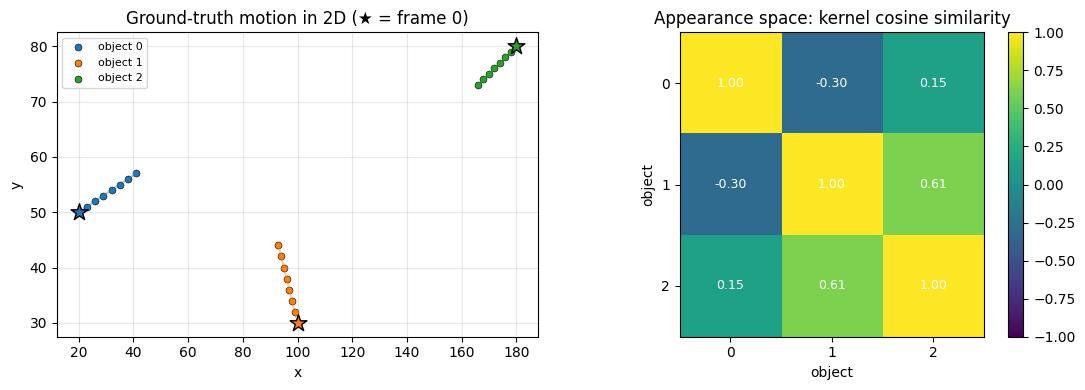

In [10]:
fig, (ax_pos, ax_emb) = plt.subplots(1, 2, figsize=(11, 4))
cmap = plt.get_cmap("tab10")

# (left) ground-truth motion: where each identity actually is.
for o in range(N_OBJS):
    track = torch.stack([positions[o] + k * velocities[o] for k in range(N_FRAMES)])
    ax_pos.plot(track[:, 0], track[:, 1], "-", color=cmap(o), alpha=0.4)
    ax_pos.scatter(
        track[:, 0],
        track[:, 1],
        color=cmap(o),
        s=25,
        edgecolor="black",
        linewidth=0.4,
        label=f"object {o}",
    )
    ax_pos.scatter(
        track[0, 0],
        track[0, 1],
        color=cmap(o),
        s=160,
        marker="*",
        edgecolor="black",
        zorder=3,
    )
ax_pos.set_title("Ground-truth motion in 2D (★ = frame 0)")
ax_pos.set_xlabel("x")
ax_pos.set_ylabel("y")
ax_pos.legend(fontsize=8)
ax_pos.grid(alpha=0.3)

# (right) appearance space: cosine similarity between identity kernels.
sim = kernels @ kernels.T
im = ax_emb.imshow(sim.numpy(), cmap="viridis", vmin=-1, vmax=1)
ax_emb.set_title("Appearance space: kernel cosine similarity")
ax_emb.set_xlabel("object")
ax_emb.set_ylabel("object")
ax_emb.set_xticks(range(N_OBJS))
ax_emb.set_yticks(range(N_OBJS))
for i in range(N_OBJS):
    for j in range(N_OBJS):
        ax_emb.text(
            j,
            i,
            f"{sim[i, j]:.2f}",
            ha="center",
            va="center",
            color="white",
            fontsize=9,
        )
fig.colorbar(im, ax=ax_emb, fraction=0.046)
plt.tight_layout()
plt.show()


## Run the tracker

Each step takes one frame's detections and a `FrameContext` (which
carries the frame index and a delta-t for state evolution). The
wrapper holds the snapshot internally and threads `next_id` through.


In [11]:
all_results = []
for k, dets in enumerate(clip):
    ctx = FrameContext.make(frame_idx=k, delta=1 / 15.0, fps=15.0, stream_key=0)
    res = ms.step(stream_key=0, detections=dets, ctx=ctx)
    all_results.append(res)
    print(
        f"frame {k}: snapshot={res.snapshot.batch_size[0]} live, ids={res.ids.tolist()}"
    )


frame 0: snapshot=3 live, ids=[1, 2, 3]
frame 1: snapshot=3 live, ids=[1, 2, 3]
frame 2: snapshot=3 live, ids=[1, 2, 3]
frame 3: snapshot=3 live, ids=[1, 2, 3]
frame 4: snapshot=3 live, ids=[1, 2, 3]
frame 5: snapshot=3 live, ids=[1, 2, 3]
frame 6: snapshot=3 live, ids=[1, 2, 3]
frame 7: snapshot=3 live, ids=[1, 2, 3]


Three tracklets live across all eight frames. Their IDs (1, 2, 3)
are stable — the tracker correctly matches every shuffled detection
back to the right identity by cosine similarity on the kernel.


## Visualize

We'll draw the trajectories color-coded by tracker-assigned ID.
Each marker is one detection, located at its 2D position; the
color tells us which tracklet the tracker thinks it belongs to.


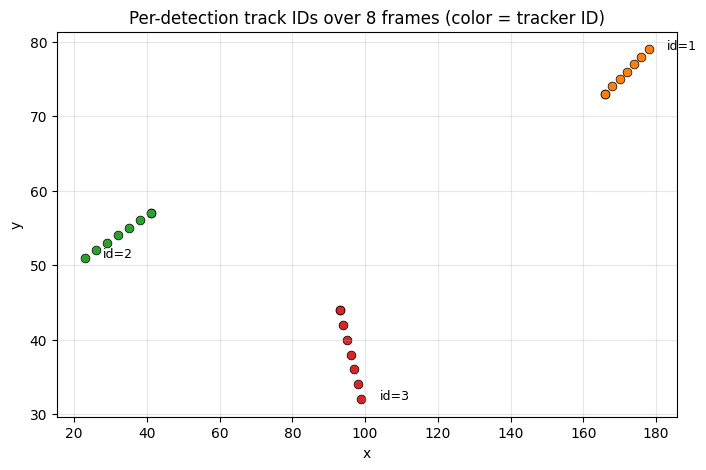

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
cmap = plt.get_cmap("tab10")

for k, (dets, res) in enumerate(zip(clip, all_results)):
    # The snapshot's id field aligns with the matched-then-appended order.
    # For this minimal example we re-derive per-detection IDs by walking
    # the snapshot in detection-index order. (Notebook 6 shows a robust
    # version of this for ground-truth evaluation.)
    ids = res.snapshot.id
    pos = res.snapshot.position
    for n, tid in enumerate(ids):
        ax.scatter(
            pos[n, 0],
            pos[n, 1],
            color=cmap(int(tid) % 10),
            s=40,
            edgecolor="black",
            linewidth=0.5,
        )
        if k == 0:
            ax.text(pos[n, 0] + 5, pos[n, 1], f"id={int(tid)}", fontsize=9)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Per-detection track IDs over 8 frames (color = tracker ID)")
ax.grid(alpha=0.3)
plt.show()


Each color forms a coherent trajectory in (x, y) — the tracker
preserved identity across all 8 frames, despite per-frame
detection shuffling.

## What's next

- **Notebook 2** unpacks the typed records (`Tracklets`,
  `Detections`, `CostExpression`, `MatchOutcome`, `Gate`) and
  explains *why* unitrack uses immutable snapshots.
- **Notebook 3** visualizes every cost and gate primitive in the library.
- **Notebook 4** builds richer pipelines with `Sequential`,
  `Parallel`, `Gated`, `Filter`, and `Iterate`.
- **Notebook 5** introduces state evolution (Kalman, EMA) and
  lifecycle (Tentative → Active → Lost → Removed).
- **Notebook 6** assembles a K=2 cascaded canonical configuration
  and compares cascaded vs parallel fusion end-to-end.
